<script src="/course_model/toc.js"></script>

# Decision Trees

A decision tree is a supervised machine learning algorithm used for classification and regression tasks. It works by splitting the data into subsets based on the value of input features, creating a tree-like model of decisions.

**Outcomes**:
- Use a decision tree
    - Describe how data should be transformed
    - Create a decision tree from a dataset
    - Intepret the printout of a decision tree
    - Measure the category performance of a decision tree model using accuracy, precision, and recall
    - Measure the numerical prediction performance of a decision tree model using RMSE and R^2
- Describe how to reduce overfitting with leaf size and max depth
- Describe the difference between whitebox and blackbox modeling techniques (older statistical methods v. newer machine learning)
- Explain how a test/train split can help reduce overfitting
- Explain how cross validation can help reduce overfitting
- Explain why a decision tree can use a virtually unlimited number of features without overfitting (unlike regression).

**Links**:
- [Quizlet](https://quizlet.com/1148647471/course-model-decision-trees-flash-cards/?i=2up6jq&x=1qqt)
- [template](template.ipynb) and [affairs1](affairs.csv) and [affairs2](affairs_occupations.csv) datasets

**Resources**:
- [Decision Trees - Entropy explained](https://mlu-explain.github.io/decision-tree/)
- [Bias and variance](https://mlu-explain.github.io/bias-variance/)
- [Train and Test and Validation](https://mlu-explain.github.io/train-test-validation/)
- [Cross Validation](https://mlu-explain.github.io/cross-validation/)
- [Random Forest](https://mlu-explain.github.io/random-forest/)

# Decision Trees

A decision tree is a supervised machine learning algorithm used for classification and regression tasks. It works by splitting the data into subsets based on the value of input features, creating a tree-like model of decisions.

Key Concepts:

- Trees can predict either categorical (classification) and continuous (regression) outcomes.
- Use data splitting (train/test) to evaluate the model's performance on unseen data.
- Do not scale variables in decision trees (as they are not distance-based algorithms).
- We use one-hot encoding for text variables.

Problems:

- Overfitting is a major problem with decision trees.
    - Decision trees can build very elaborate trees. In the worse case, these will perfectly memorize the training data, meaning that they may not work well on new data.
    - Techniques to prevent overfitting include pruning the tree, setting a maximum depth, or requiring a minimum number of samples per leaf node.

Interpretation:

- Overall model:
    - We can visualize the decision tree structure to understand the decision rules.
    - Feature importance can be assessed to see which features contribute most to the predictions.
- Individual predictions:
    - We can evaluate the model's performance using metrics like accuracy, precision, recall, F1-score for classification, or mean squared error for regression.

## Topic: Test and train data split

In contrast to a classical approach, modern machine learning practices often involve splitting the dataset into training and testing sets to evaluate model performance. In this approach, we do not evaluate individual coefficients for significance, but rather focus on overall model performance metrics. Because we are not focusing on an understandable model, we can use more complex models that may not be easily interpretable. However, this means that we need to be careful to avoid overfitting.

Key Concepts:
- The dataset is divided into two parts: the training set and the testing set. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.
- Common splits include 70/30 or 80/20, where 70% or 80% of the data is used for training, and the remaining 30% or 20% is used for testing.
- The goal is to ensure that the model generalizes well to new data, rather than just memorizing the training data.

Interpretation:
- Measure performance on the training set. How well does our model account for the data it was trained on? If this is very low, our data may not be suitable for modeling.
- Measure performance on the test set. How well does our model perform on new, unseen data? This is typically lower than performance on the training set.
- In this approach, we typically do not interpret individual coefficients for significance. Instead, we focus on the overall predictive performance of the model.

*Cross-validation*

Cross-validation is a technique used to assess how the results of a statistical analysis will generalize to an independent dataset. It is mainly used in settings where the goal is prediction, and one wants to estimate how accurately a predictive model will perform in practice.

The basic idea of cross-validation is to partition the data into subsets, train the model on some subsets (training set), and validate it on the remaining subsets (validation set). This process is repeated multiple times to ensure that every data point has been used for both training and validation.

### Step 1: Load and Explore the Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

df = sns.load_dataset("mpg").dropna()

# Create a new column 'make' by splitting the 'name' column and taking the first word
df['make'] = df['name'].apply(lambda x: x.split(' ')[0])

df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,make
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,chevrolet
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,buick
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,plymouth
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,amc
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,ford
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl,ford
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup,vw
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage,dodge
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger,ford


### Step 2: Define predictors and target

In [2]:
target = 'mpg'
numeric_features = ['weight', 'horsepower', 'displacement', 'acceleration', 'cylinders']
categorical_features = [ 'origin', 'make']

X = df[numeric_features + categorical_features]
y = df[target]

# One-Hot Encode the categorical predictors
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=False)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42
)


### Step 3: Prediction of mpg (continuous value)

The decision tree regressor predicts the miles per gallon (mpg) based on the input features. It splits the data into regions with similar mpg values, allowing us to estimate the fuel efficiency of a car given its attributes.

In [3]:
# Use normal linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R^2:", r2_lr)


Linear Regression MAE: 3.4386653125824713
Linear Regression RMSE: 18.416796850299363
Linear Regression R^2: 0.6348272785373763


In [4]:
# Use a decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create and fit decision tree
tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=3,          # limit depth for stability and interpretability
    min_samples_leaf=5
)
tree.fit(X_train, y_train)

# Predict on test set
y_pred = tree.predict(X_test)

# Calculate metrics, using mae (mean absolute error), rmse (root mean squared error), r2 (R-squared)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

# Feature importance, which is defined as the total reduction of the criterion (MSE) brought by that feature.
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=False)

feature_importances

MAE: 3.389427325074965
RMSE: 19.73045119753326
R^2: 0.6087798210484368


,feature,importance
2,displacement,0.762519
1,horsepower,0.190945
0,weight,0.039471
18,make_datsun,0.007065
33,make_plymouth,0.000000
26,make_mercedes,0.000000
27,make_mercedes-benz,0.000000
28,make_mercury,0.000000
29,make_nissan,0.000000
30,make_oldsmobile,0.000000


### Measure accuracy on test set.



In [5]:
# Measure accuracy on test set.
y_pred = tree.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MAE: 3.389427325074965
RMSE: 19.73045119753326
R^2: 0.6087798210484368


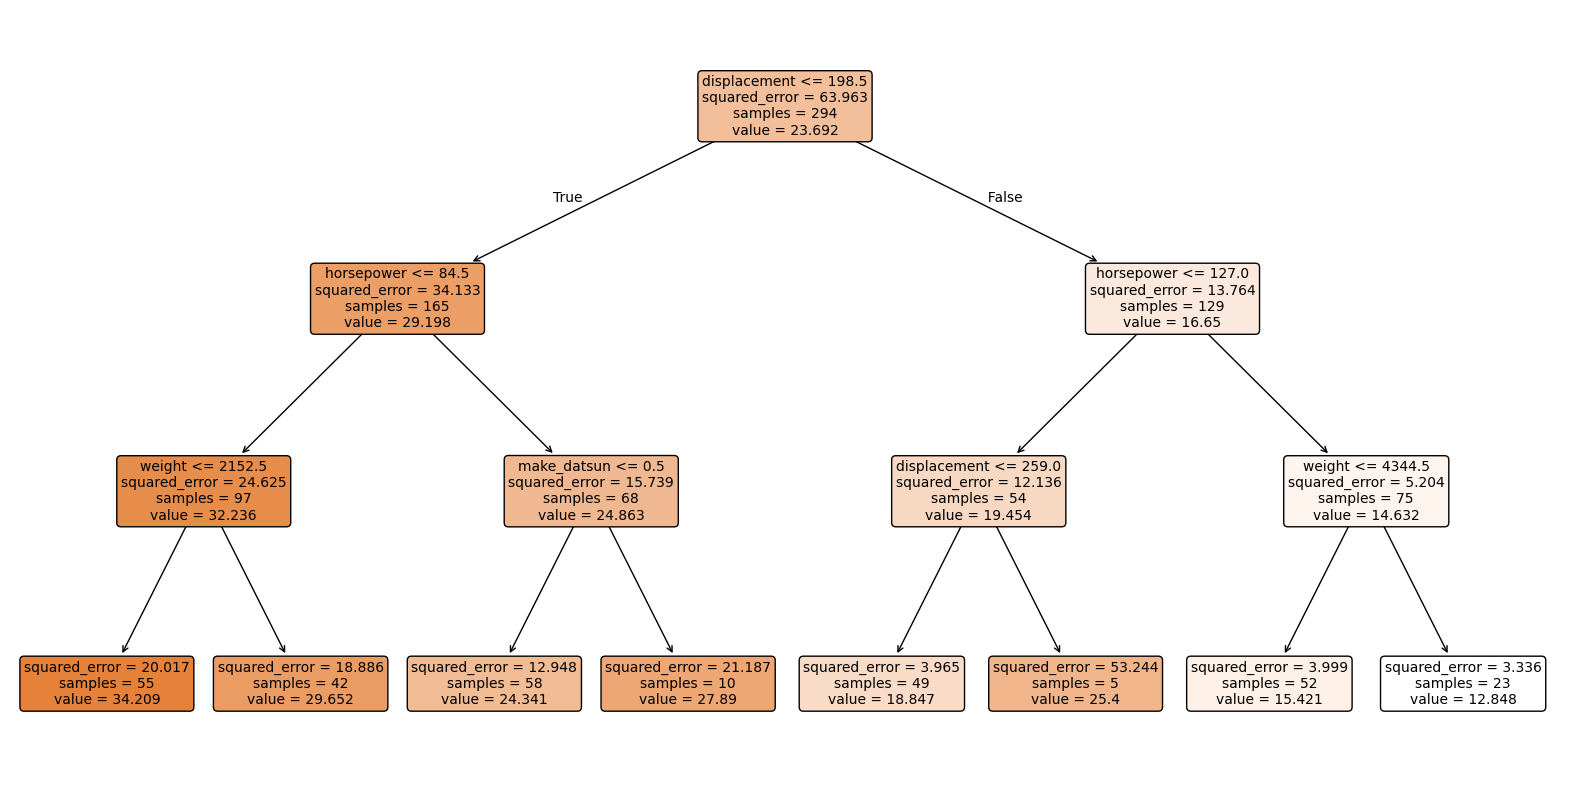

In [6]:
# Visualize tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X_train.columns, filled=True, rounded=True, fontsize=10)
plt.show()

### Alternative: Predict a class variable

This is used when we want to classify data points into categories based on their features. For example, we could classify cars into different fuel efficiency categories (e.g., low, medium, high) based on their attributes.

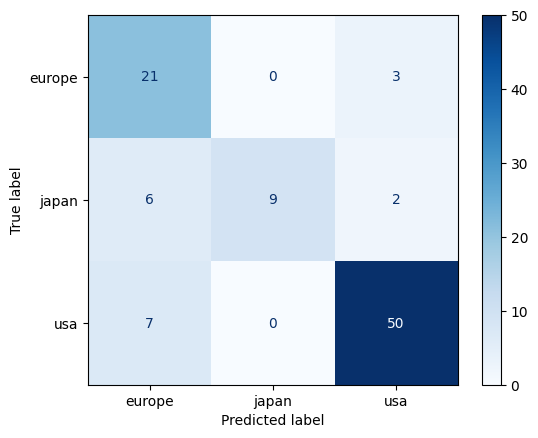

Accuracy: 0.8163265306122449
Confusion Matrix:
 [[21  0  3]
 [ 6  9  2]
 [ 7  0 50]]


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

numeric_features = ['weight', 'horsepower', 'displacement', 'acceleration', 'cylinders', 'model_year']
categorical_features = ['make']

X = df[numeric_features + categorical_features]
y = df['origin']

# One-hot encode
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42
)

clf = DecisionTreeClassifier(
    random_state=42,
    max_depth=3,
    min_samples_leaf=5
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=clf.classes_, cmap='Blues')
plt.show()


print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)


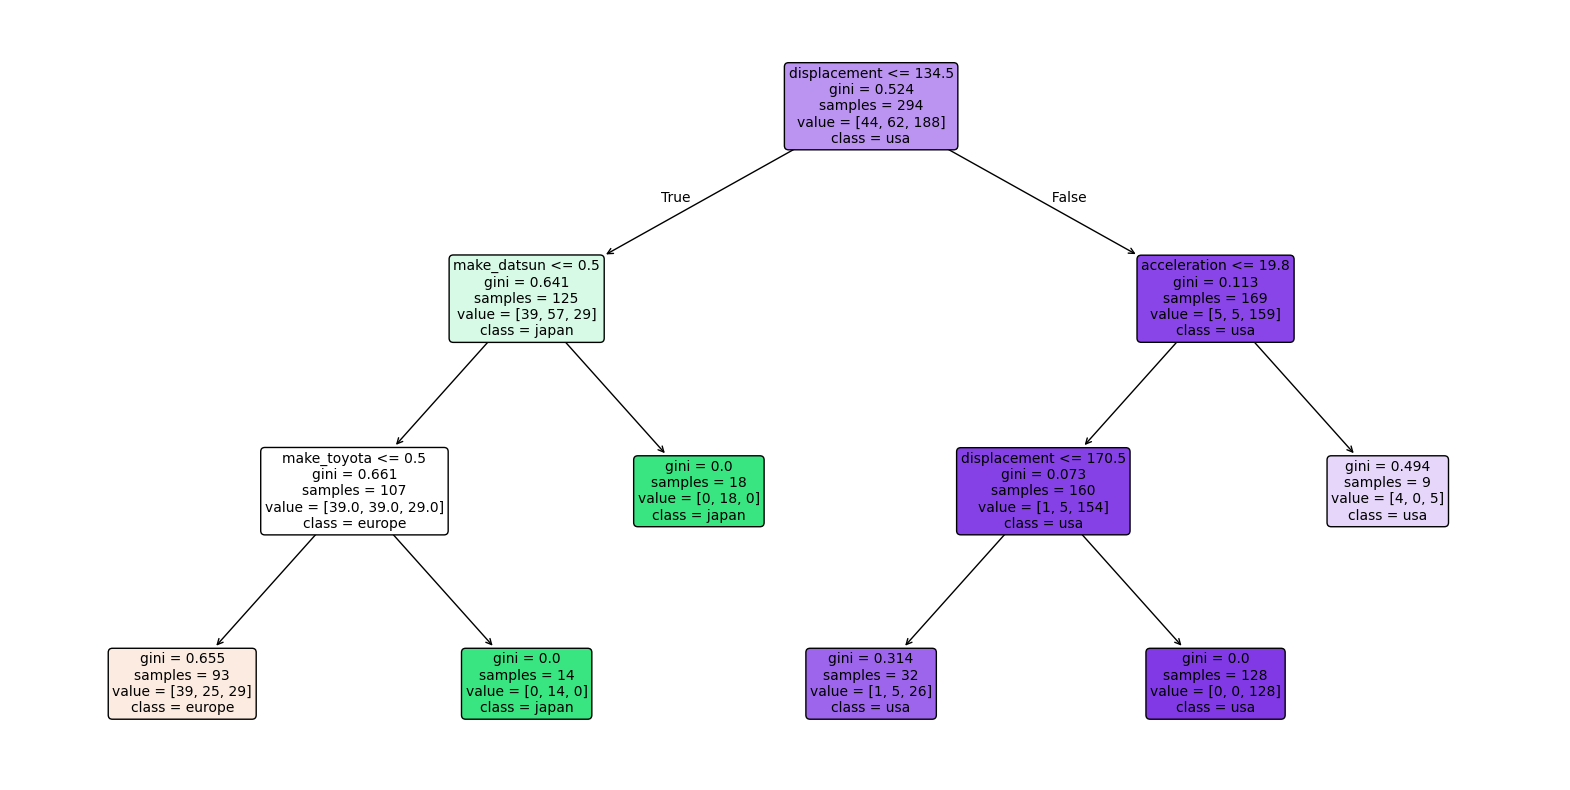

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Show decision tree. The top line shows the decision rule.
# The second line shows gini, which is defined as 1 - sum(p_i^2) for each class i, 
#   where p_i is the proportion of samples of class i at that node.
# Gini ranges from 0 (pure node) to 0.5 (impure node with equal class distribution).
# The line with value = ... shows the number of samples at that node.
# The last line shows the most common class distribution at that node.

plt.figure(figsize=(20,10))
plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=[str(c) for c in clf.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()